In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('netflix_titles.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [7]:
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Data types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


Step 2: Data Cleaning and Preparation

In [8]:
# Create a copy of the original dataset
netflix = df.copy()

In [9]:
# 1. Check and remove duplicate records
print("Duplicate rows:", netflix.duplicated().sum())
netflix = netflix.drop_duplicates()

Duplicate rows: 0


In [10]:
# 2. Handle missing values

columns_to_fill = [
    "director",
    "cast",
    "country",
    "rating",
    "duration",
    "listed_in"
]

for col in columns_to_fill:
    netflix[col] = netflix[col].fillna("Unknown")

In [11]:
# 3. Convert date_added into datetime format

netflix["date_added"] = pd.to_datetime(
    netflix["date_added"].str.strip(),
    errors="coerce"
)

In [12]:
# 4. Extract date-related information

netflix["year_added"] = netflix["date_added"].dt.year
netflix["month_added"] = netflix["date_added"].dt.month

In [13]:
# 5. Extract numeric duration

netflix["duration_value"] = pd.to_numeric(
    netflix["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

In [14]:
# 6. Check the cleaned dataset

print("Cleaned shape:", netflix.shape)

print("\nRemaining missing values:")
print(netflix.isnull().sum())

print("\nDuplicate rows after cleaning:", netflix.duplicated().sum())

display(netflix.head())

Cleaned shape: (8807, 15)

Remaining missing values:
show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
year_added        10
month_added       10
duration_value     3
dtype: int64

Duplicate rows after cleaning: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,2.0


Step 3: Content Overview

How much content is Movie vs TV Show?

Which release years have the most content?

What are the most common content ratings?

Movies vs TV shows

In [15]:
content_type = netflix["type"].value_counts()

print(content_type)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [16]:
content_type_percentage = (
    netflix["type"].value_counts(normalize=True) * 100
).round(2)

print(content_type_percentage)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


Release Year Distribution

In [17]:
release_year_counts = (
    netflix["release_year"]
    .value_counts()
    .sort_index()
)

print(release_year_counts)

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


In [18]:
top_release_years = (
    netflix["release_year"]
    .value_counts()
    .head(10)
)

print(top_release_years)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


Content Ratings

In [19]:
rating_counts = netflix["rating"].value_counts()

print(rating_counts)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [20]:
top_ratings = netflix["rating"].value_counts().head(10)

print(top_ratings)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


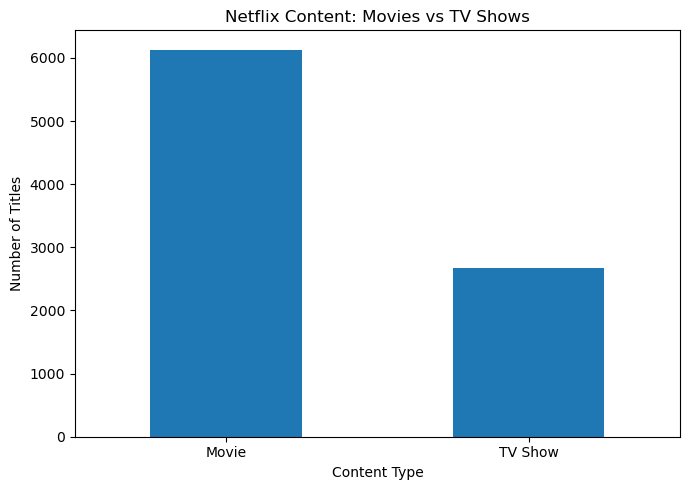

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

content_type.plot(kind="bar")

plt.title("Netflix Content: Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Step 4: Release Trend Analysis

yearly content counts

In [22]:
yearly_content = (
    netflix.groupby(["release_year", "type"])
    .size()
    .reset_index(name="count")
)

display(yearly_content.head(10))

,release_year,type,count
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3
5,1945,TV Show,1
6,1946,Movie,1
7,1946,TV Show,1
8,1947,Movie,1
9,1954,Movie,2


Movie vs TV Show trend

In [23]:
yearly_pivot = yearly_content.pivot(
    index="release_year",
    columns="type",
    values="count"
).fillna(0)

display(yearly_pivot.tail(15))

type,Movie,TV Show
release_year,,
2007,74.0,14.0
2008,113.0,23.0
2009,118.0,34.0
2010,154.0,40.0
2011,145.0,40.0
2012,173.0,64.0
2013,225.0,63.0
2014,264.0,88.0
2015,398.0,162.0


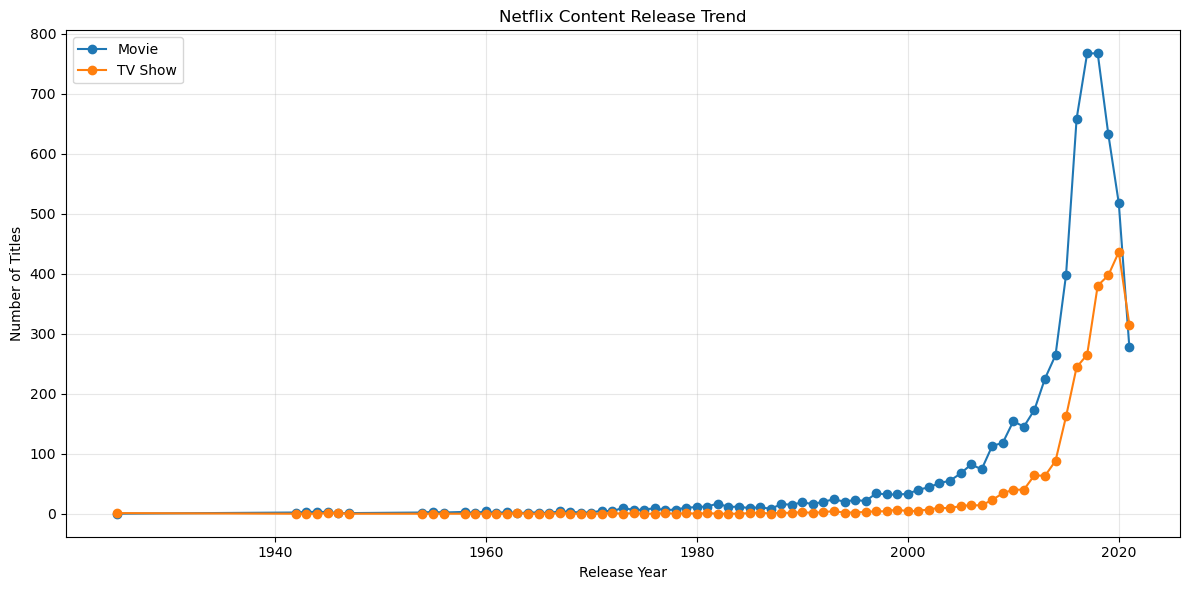

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_pivot.index,
    yearly_pivot["Movie"],
    marker="o",
    label="Movie"
)

plt.plot(
    yearly_pivot.index,
    yearly_pivot["TV Show"],
    marker="o",
    label="TV Show"
)

plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Focus on recent years

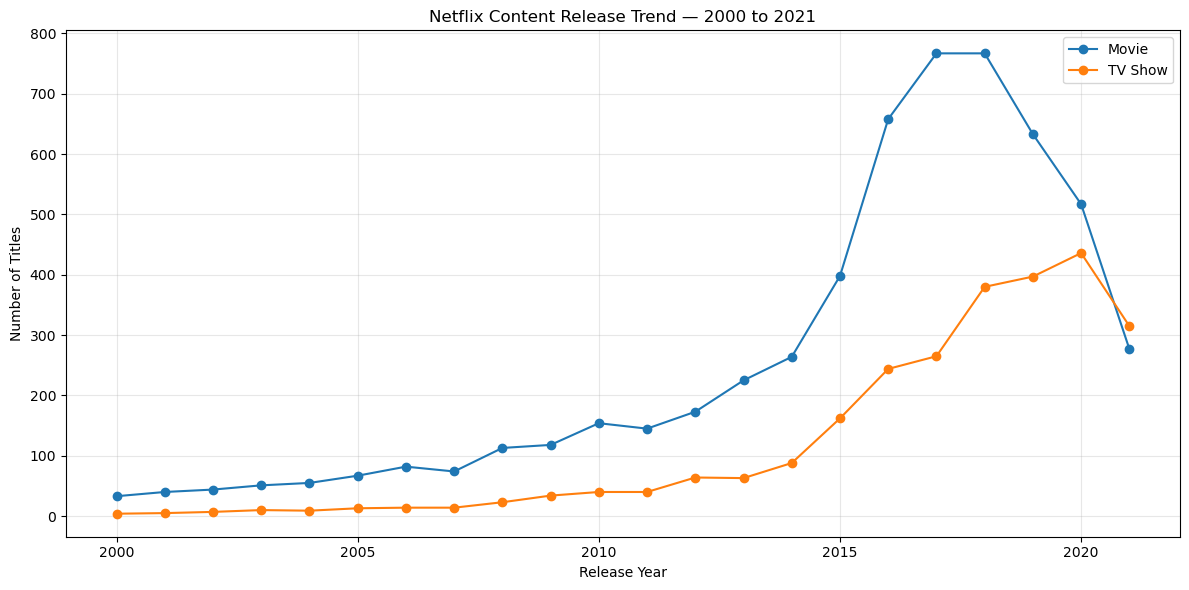

In [25]:
recent_content = yearly_pivot[
    yearly_pivot.index >= 2000
]

plt.figure(figsize=(12, 6))

plt.plot(
    recent_content.index,
    recent_content["Movie"],
    marker="o",
    label="Movie"
)

plt.plot(
    recent_content.index,
    recent_content["TV Show"],
    marker="o",
    label="TV Show"
)

plt.title("Netflix Content Release Trend — 2000 to 2021")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Step 5: Genre Analysis

Extract individual genres

In [26]:
genre_df = netflix[["show_id", "type", "listed_in"]].copy()

genre_df["genre"] = genre_df["listed_in"].str.split(", ")

genre_df = genre_df.explode("genre")

print("Total genre records:", len(genre_df))

display(genre_df.head(10))

Total genre records: 19323


,show_id,type,listed_in,genre
0,s1,Movie,Documentaries,Documentaries
1,s2,TV Show,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows
1,s2,TV Show,"International TV Shows, TV Dramas, TV Mysteries",TV Dramas
1,s2,TV Show,"International TV Shows, TV Dramas, TV Mysteries",TV Mysteries
2,s3,TV Show,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows
2,s3,TV Show,"Crime TV Shows, International TV Shows, TV Act...",International TV Shows
2,s3,TV Show,"Crime TV Shows, International TV Shows, TV Act...",TV Action & Adventure
3,s4,TV Show,"Docuseries, Reality TV",Docuseries
3,s4,TV Show,"Docuseries, Reality TV",Reality TV
4,s5,TV Show,"International TV Shows, Romantic TV Shows, TV ...",International TV Shows


Count the most common genres

In [27]:
genre_counts = (
    genre_df["genre"]
    .value_counts()
    .reset_index()
)

genre_counts.columns = ["Genre", "Title Count"]

display(genre_counts.head(15))

,Genre,Title Count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


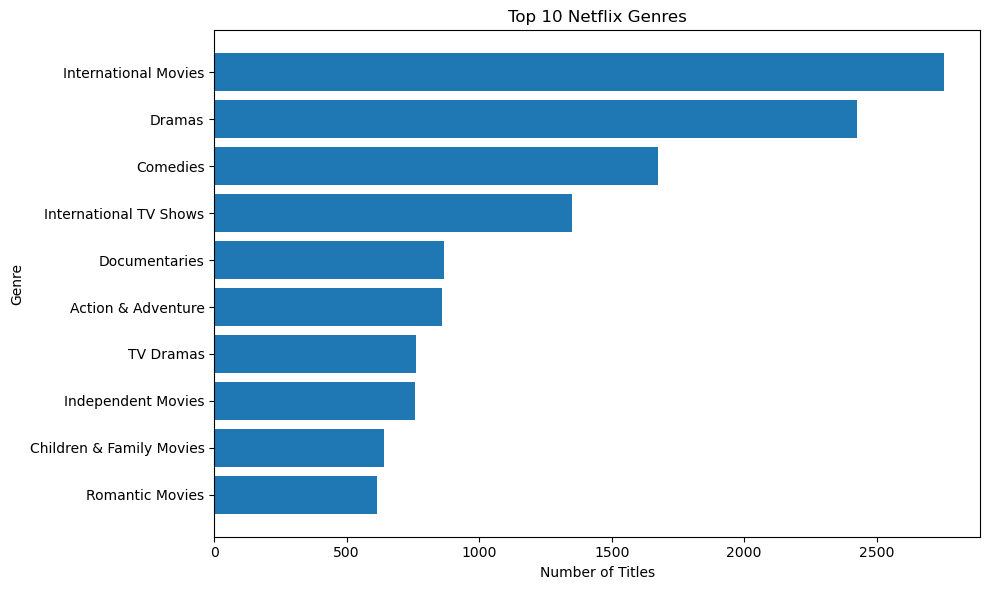

In [28]:
top_genres = genre_counts.head(10).sort_values(
    "Title Count"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_genres["Genre"],
    top_genres["Title Count"]
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

Genre mix by Movie vs TV Show

In [29]:
genre_type_counts = (
    genre_df
    .groupby(["genre", "type"])
    .size()
    .reset_index(name="Count")
)

top_genres_list = genre_counts.head(10)["Genre"]

genre_type_top10 = genre_type_counts[
    genre_type_counts["genre"].isin(top_genres_list)
]

display(
    genre_type_top10
    .sort_values("Count", ascending=False)
    .head(20)
)

,genre,type,Count
16,International Movies,Movie,2752
12,Dramas,Movie,2427
7,Comedies,Movie,1674
17,International TV Shows,TV Show,1351
10,Documentaries,Movie,869
0,Action & Adventure,Movie,859
34,TV Dramas,TV Show,763
15,Independent Movies,Movie,756
4,Children & Family Movies,Movie,641
24,Romantic Movies,Movie,616


Step 6: Content Rating Analysis

Clean the rating column

In [30]:
# Identify invalid rating values
invalid_ratings = netflix[
    netflix["rating"].str.contains("min", case=False, na=False)
]

print("Invalid rating records:")
display(invalid_ratings[["title", "type", "rating", "duration"]])

Invalid rating records:


,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,Unknown
5794,Louis C.K.: Hilarious,Movie,84 min,Unknown
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,Unknown


In [31]:
netflix["rating"] = netflix["rating"].replace(
    ["74 min", "84 min", "66 min"],
    "Unknown"
)

print(netflix["rating"].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


Analyze ratings separately for Movies and TV Shows

In [32]:
rating_type = pd.crosstab(
    netflix["rating"],
    netflix["type"]
)

display(rating_type)

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94
TV-MA,2062,1145


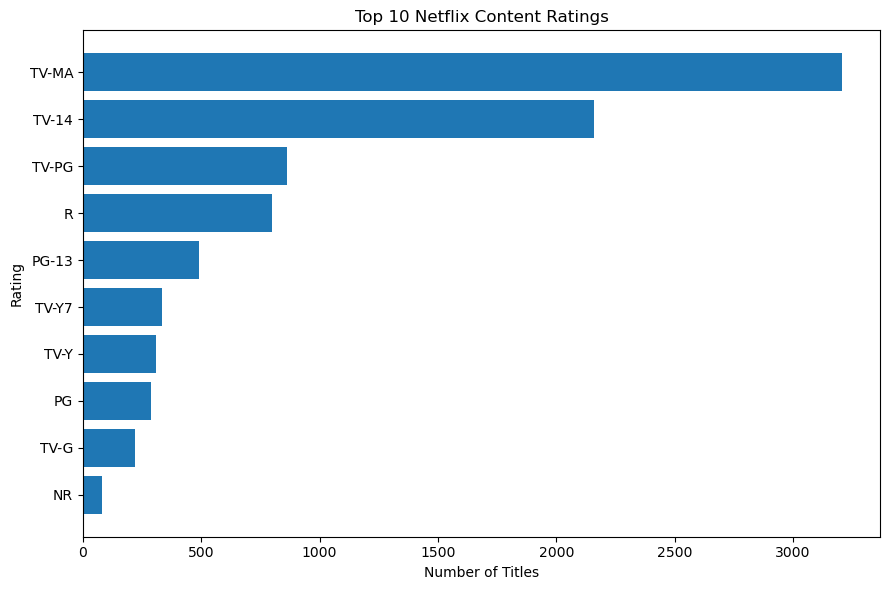

In [33]:
top_ratings = (
    netflix["rating"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_ratings.index,
    top_ratings.values
)

plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

Movie vs TV Show rating comparison

In [34]:
top_rating_names = (
    netflix["rating"]
    .value_counts()
    .head(6)
    .index
)

rating_comparison = (
    pd.crosstab(
        netflix["rating"],
        netflix["type"]
    )
    .loc[top_rating_names]
)

display(rating_comparison)

type,Movie,TV Show
rating,,
TV-MA,2062,1145
TV-14,1427,733
TV-PG,540,323
R,797,2
PG-13,490,0
TV-Y7,139,195


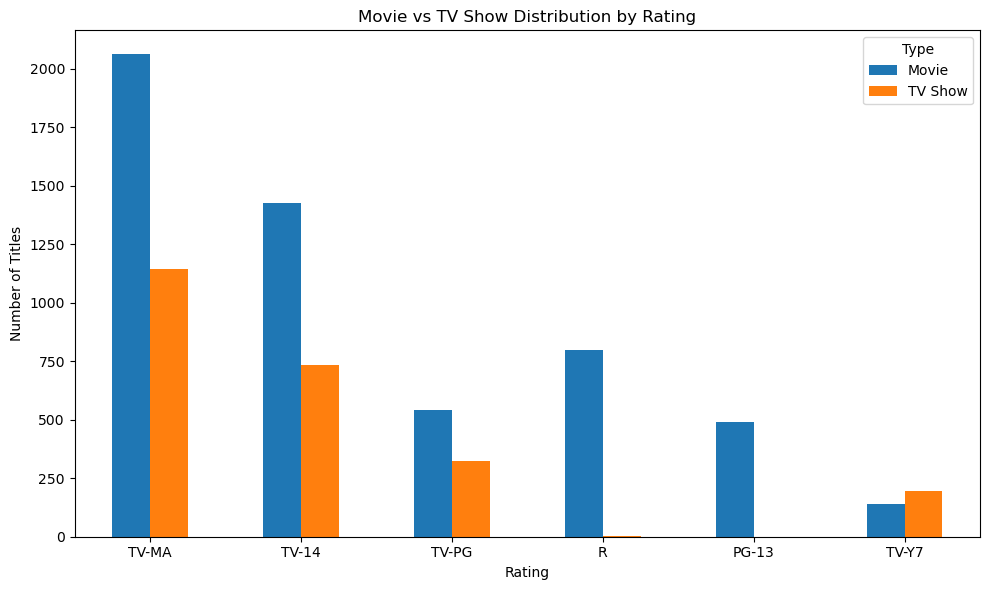

In [35]:
rating_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Movie vs TV Show Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.legend(title="Type")

plt.tight_layout()
plt.show()

Step 7: Country Analysis 🌍

country data

In [36]:
country_df = netflix[["show_id", "type", "country"]].copy()

country_df["country"] = country_df["country"].str.split(", ")

country_df = country_df.explode("country")

# Remove Unknown values for country-level analysis
country_df = country_df[
    country_df["country"] != "Unknown"
]

print("Country records:", len(country_df))

display(country_df.head(10))

Country records: 10014


,show_id,type,country
0,s1,Movie,United States
1,s2,TV Show,South Africa
4,s5,TV Show,India
7,s8,Movie,United States
7,s8,Movie,Ghana
7,s8,Movie,Burkina Faso
7,s8,Movie,United Kingdom
7,s8,Movie,Germany
7,s8,Movie,Ethiopia
8,s9,TV Show,United Kingdom


Find the top 10 countries

In [37]:
country_counts = (
    country_df["country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["Country", "Title Count"]

display(country_counts.head(10))

,Country,Title Count
0,United States,3689
1,India,1046
2,United Kingdom,804
3,Canada,445
4,France,393
5,Japan,318
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


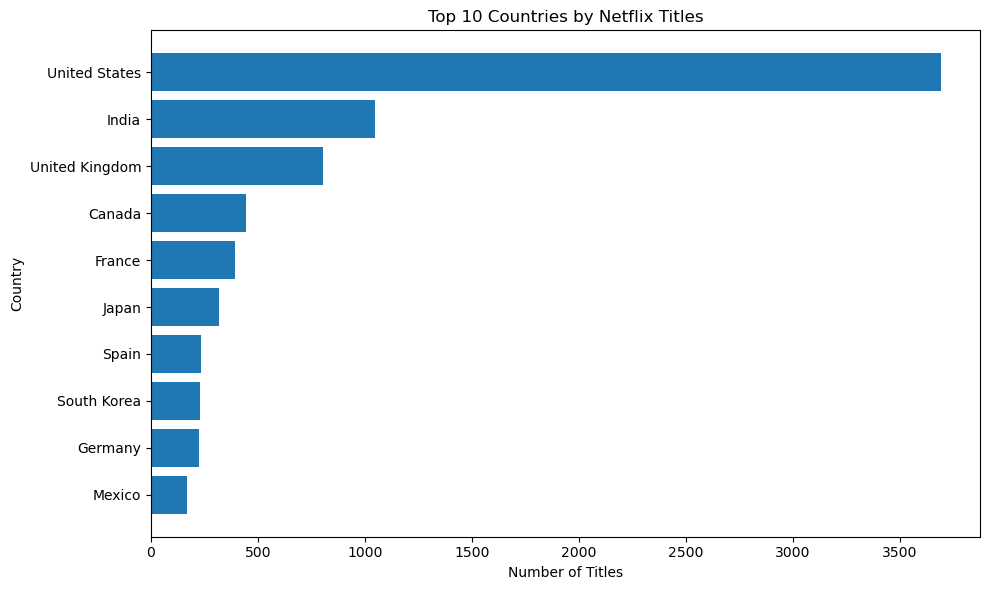

In [38]:
top_countries = (
    country_counts
    .head(10)
    .sort_values("Title Count")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"],
    top_countries["Title Count"]
)

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

Movie vs TV Show by country

In [39]:
country_type = (
    country_df
    .groupby(["country", "type"])
    .size()
    .reset_index(name="Count")
)

top_country_names = country_counts.head(10)["Country"]

country_type_top10 = country_type[
    country_type["country"].isin(top_country_names)
]

display(
    country_type_top10
    .sort_values(
        ["country", "Count"],
        ascending=[True, False]
    )
)

,country,type,Count
28,Canada,Movie,319
29,Canada,TV Show,126
53,France,Movie,303
54,France,TV Show,90
56,Germany,Movie,182
57,Germany,TV Show,44
68,India,Movie,962
69,India,TV Show,84
82,Japan,TV Show,199
81,Japan,Movie,119


Step 8: Duration & Seasons Analysis 🎬📺

Movie duration

In [40]:
movies = netflix[netflix["type"] == "Movie"].copy()

movie_duration = movies["duration_value"].dropna()

print("Number of movies:", len(movies))
print("\nMovie duration statistics:")
print(movie_duration.describe())

Number of movies: 6131

Movie duration statistics:
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64


the most common movie durations

In [41]:
common_movie_durations = (
    movie_duration
    .value_counts()
    .head(10)
    .sort_values()
)

print(common_movie_durations)

duration_value
98.0     120
102.0    122
92.0     129
96.0     130
95.0     137
91.0     144
94.0     146
93.0     146
97.0     146
90.0     152
Name: count, dtype: int64


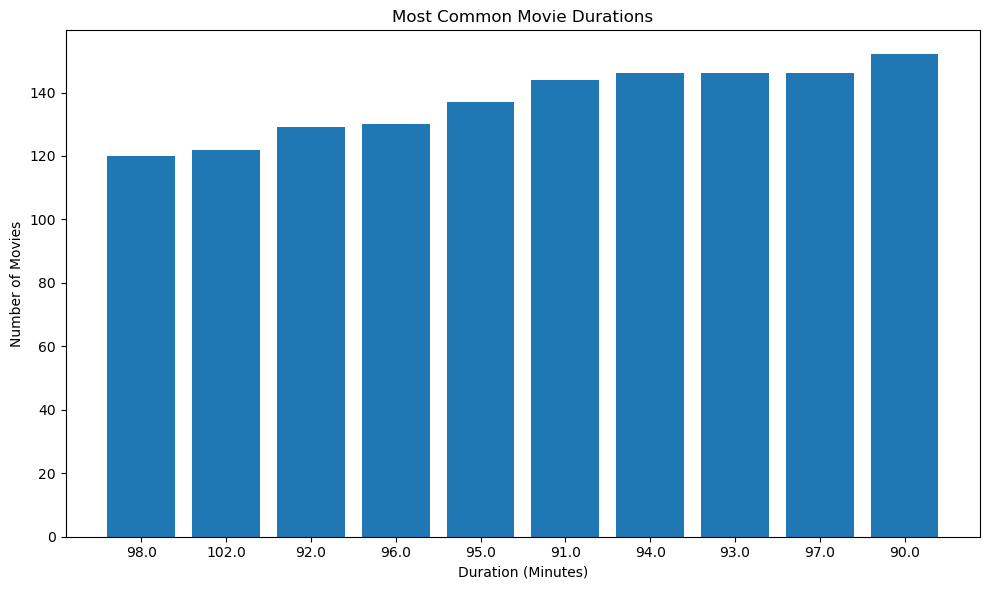

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(
    common_movie_durations.index.astype(str),
    common_movie_durations.values
)

plt.title("Most Common Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

TV Show seasons

In [43]:
tv_shows = netflix[netflix["type"] == "TV Show"].copy()

tv_seasons = tv_shows["duration_value"].dropna()

print("Number of TV Shows:", len(tv_shows))
print("\nTV Show season statistics:")
print(tv_seasons.describe())

Number of TV Shows: 2676

TV Show season statistics:
count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_value, dtype: float64


Most common number of seasons

In [44]:
common_seasons = (
    tv_seasons
    .value_counts()
    .sort_index()
)

print(common_seasons)

duration_value
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64


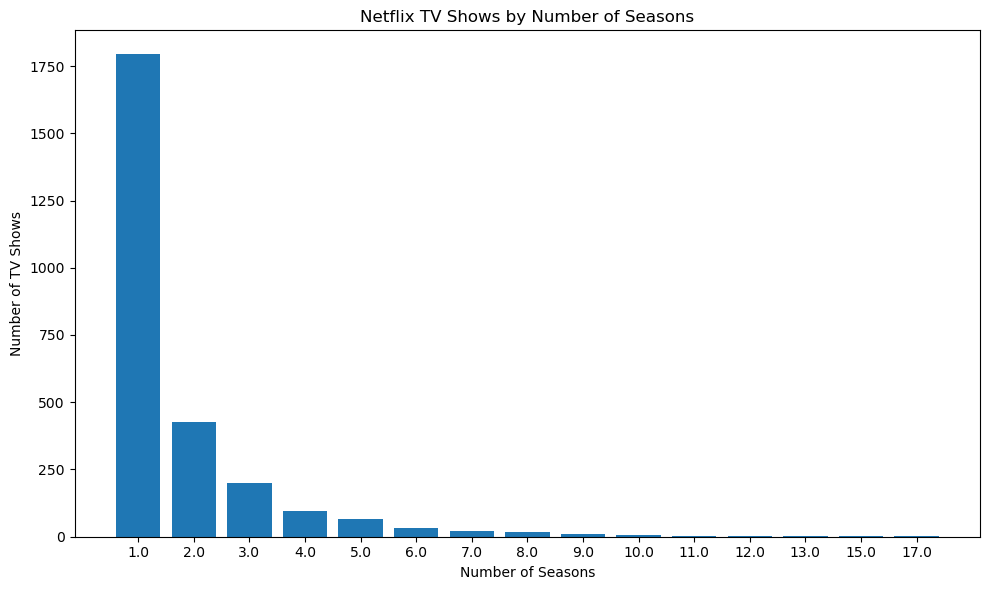

In [45]:
plt.figure(figsize=(10, 6))

plt.bar(
    common_seasons.index.astype(str),
    common_seasons.values
)

plt.title("Netflix TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.tight_layout()
plt.show()

Step 9: Netflix Content Added Over Time 📅

content added by year

In [46]:
added_yearly = (
    netflix.dropna(subset=["year_added"])
    .groupby(["year_added", "type"])
    .size()
    .reset_index(name="Count")
)

display(added_yearly)

,year_added,type,Count
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13
5,2012.0,Movie,3
6,2013.0,Movie,6
7,2013.0,TV Show,5
8,2014.0,Movie,19
9,2014.0,TV Show,5


yearly summary

In [47]:
added_year_pivot = added_yearly.pivot(
    index="year_added",
    columns="type",
    values="Count"
).fillna(0)

display(added_year_pivot)

type,Movie,TV Show
year_added,,
2008.0,1.0,1.0
2009.0,2.0,0.0
2010.0,1.0,0.0
2011.0,13.0,0.0
2012.0,3.0,0.0
2013.0,6.0,5.0
2014.0,19.0,5.0
2015.0,56.0,26.0
2016.0,253.0,176.0


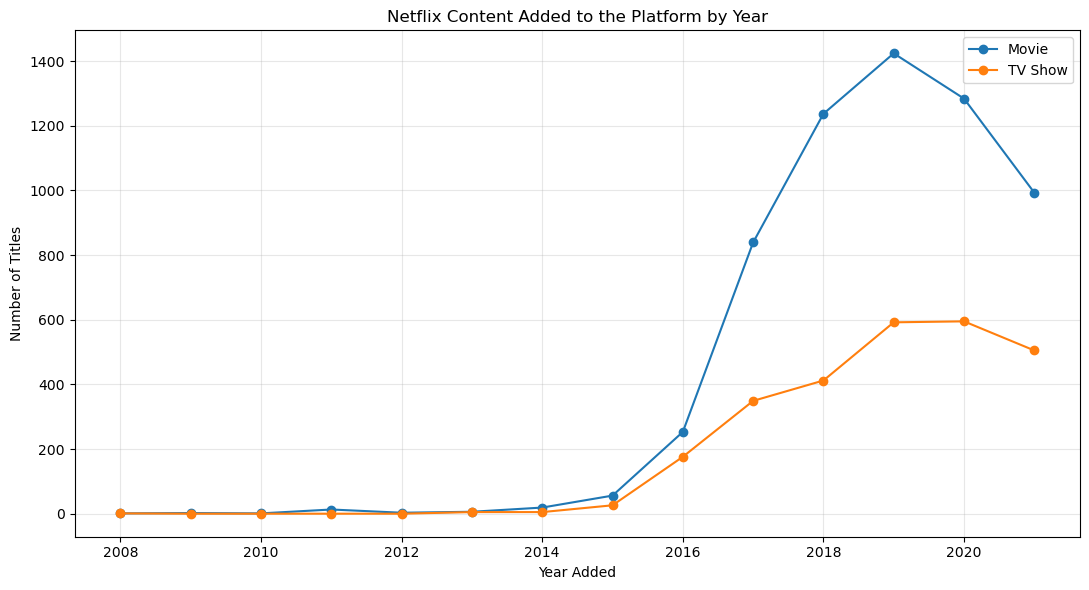

In [48]:
plt.figure(figsize=(11, 6))

plt.plot(
    added_year_pivot.index,
    added_year_pivot["Movie"],
    marker="o",
    label="Movie"
)

plt.plot(
    added_year_pivot.index,
    added_year_pivot["TV Show"],
    marker="o",
    label="TV Show"
)

plt.title("Netflix Content Added to the Platform by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analyze monthly additions

In [49]:
monthly_added = (
    netflix.dropna(subset=["month_added"])
    .groupby("month_added")
    .size()
)

print(monthly_added)

month_added
1.0     738
2.0     563
3.0     742
4.0     764
5.0     632
6.0     728
7.0     827
8.0     755
9.0     770
10.0    760
11.0    705
12.0    813
dtype: int64


In [50]:
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_added.index = monthly_added.index.map(month_names)

print(monthly_added)

month_added
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
dtype: int64


In [51]:
print(
    monthly_added
    .sort_values(ascending=False)
    .head(5)
)

month_added
July         827
December     813
September    770
April        764
October      760
dtype: int64


Step 10: Final EDA Summary & Business Insights

In [52]:
summary = {
    "Total Titles": len(netflix),
    "Movies": (netflix["type"] == "Movie").sum(),
    "TV Shows": (netflix["type"] == "TV Show").sum(),
    "Unique Release Years": netflix["release_year"].nunique(),
    "Unique Ratings": netflix["rating"].nunique(),
    "Unique Genres": genre_df["genre"].nunique(),
    "Countries": country_df["country"].nunique()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Total Titles,8807
1,Movies,6131
2,TV Shows,2676
3,Unique Release Years,74
4,Unique Ratings,15
5,Unique Genres,42
6,Countries,127


In [53]:
movie_count = (netflix["type"] == "Movie").sum()
tv_count = (netflix["type"] == "TV Show").sum()

movie_percentage = movie_count / len(netflix) * 100
tv_percentage = tv_count / len(netflix) * 100

most_common_genre = genre_counts.iloc[0]

most_common_rating = (
    netflix["rating"]
    .value_counts()
    .idxmax()
)

most_common_country = country_counts.iloc[0]

print("KEY FINDINGS")
print("-" * 50)

print(
    f"Movies: {movie_count} ({movie_percentage:.2f}%)"
)

print(
    f"TV Shows: {tv_count} ({tv_percentage:.2f}%)"
)

print(
    f"Most common genre: "
    f"{most_common_genre['Genre']} "
    f"({most_common_genre['Title Count']} titles)"
)

print(
    f"Most common rating: {most_common_rating}"
)

print(
    f"Top content-producing country: "
    f"{most_common_country['Country']} "
    f"({most_common_country['Title Count']} title associations)"
)

KEY FINDINGS
--------------------------------------------------
Movies: 6131 (69.62%)
TV Shows: 2676 (30.38%)
Most common genre: International Movies (2752 titles)
Most common rating: TV-MA
Top content-producing country: United States (3689 title associations)


# Day 2 
Step 1: Load the cleaned dataset

In [54]:
print("Shape:", netflix.shape)

print("\nColumns:")
print(netflix.columns.tolist())

print("\nFirst 5 rows:")
display(netflix.head())

Shape: (8807, 15)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'duration_value']

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,2.0


Step 2: Genre Popularity Analysis

In [55]:
# Step 2: Genre Popularity Analysis

genre_df = netflix[["show_id", "type", "listed_in"]].copy()

# Split multiple genres
genre_df["genre"] = genre_df["listed_in"].str.split(", ")

# Create one row for each genre
genre_df = genre_df.explode("genre")

# Count titles by genre
genre_counts = (
    genre_df["genre"]
    .value_counts()
    .reset_index()
)

genre_counts.columns = ["Genre", "Title Count"]

print("Total unique genres:", genre_df["genre"].nunique())

print("\nTop 10 genres:")
display(genre_counts.head(10))

Total unique genres: 42

Top 10 genres:


,Genre,Title Count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


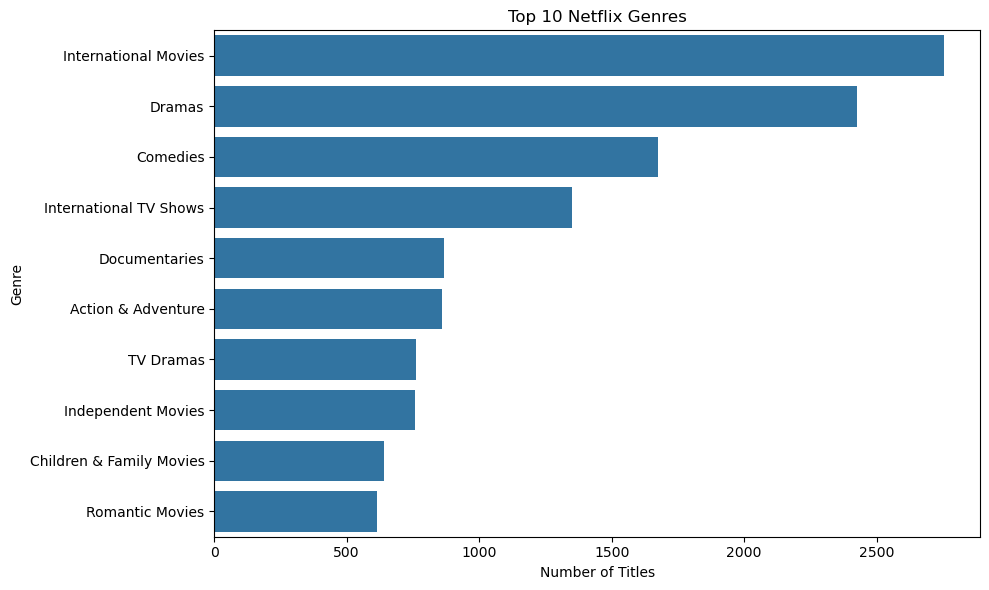

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

top_10_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_genres,
    x="Title Count",
    y="Genre"
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Step 3: Genre Mix by Content Type

Are the major genres driven mainly by Movies or TV Shows?

In [57]:
# Step 3: Genre distribution by content type

genre_type = (
    genre_df
    .groupby(["genre", "type"])
    .size()
    .reset_index(name="Title Count")
)

# Keep only the top 10 genres identified earlier
top_genres = genre_counts.head(10)["Genre"]

genre_type_top10 = genre_type[
    genre_type["genre"].isin(top_genres)
]

display(
    genre_type_top10
    .sort_values(["genre", "Title Count"], ascending=[True, False])
)

,genre,type,Title Count
0,Action & Adventure,Movie,859
4,Children & Family Movies,Movie,641
7,Comedies,Movie,1674
10,Documentaries,Movie,869
12,Dramas,Movie,2427
15,Independent Movies,Movie,756
16,International Movies,Movie,2752
17,International TV Shows,TV Show,1351
24,Romantic Movies,Movie,616
34,TV Dramas,TV Show,763


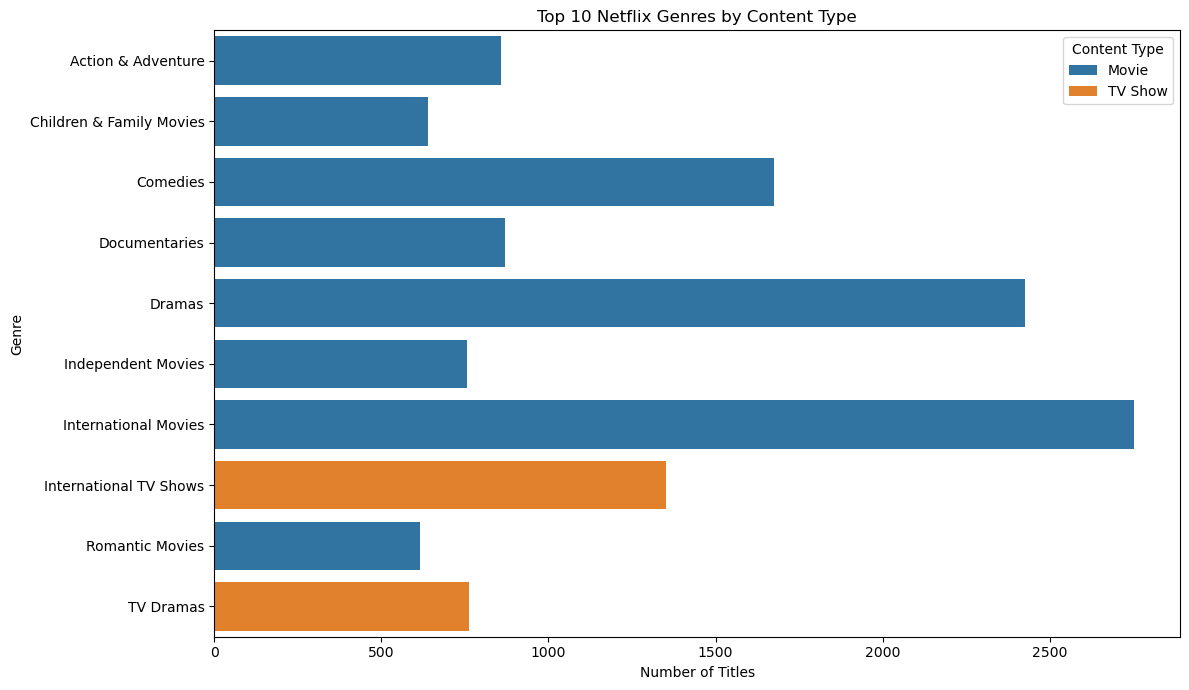

In [58]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=genre_type_top10,
    x="Title Count",
    y="genre",
    hue="type"
)

plt.title("Top 10 Netflix Genres by Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.legend(title="Content Type")
plt.tight_layout()
plt.show()

Step 4: Content Rating Analysis

In [59]:
# Step 4: Content Rating Analysis

rating_counts = (
    netflix["rating"]
    .value_counts()
    .reset_index()
)

rating_counts.columns = ["Rating", "Title Count"]

print("Total unique ratings:", netflix["rating"].nunique())

print("\nTop 10 ratings:")
display(rating_counts.head(10))

Total unique ratings: 15

Top 10 ratings:


,Rating,Title Count
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


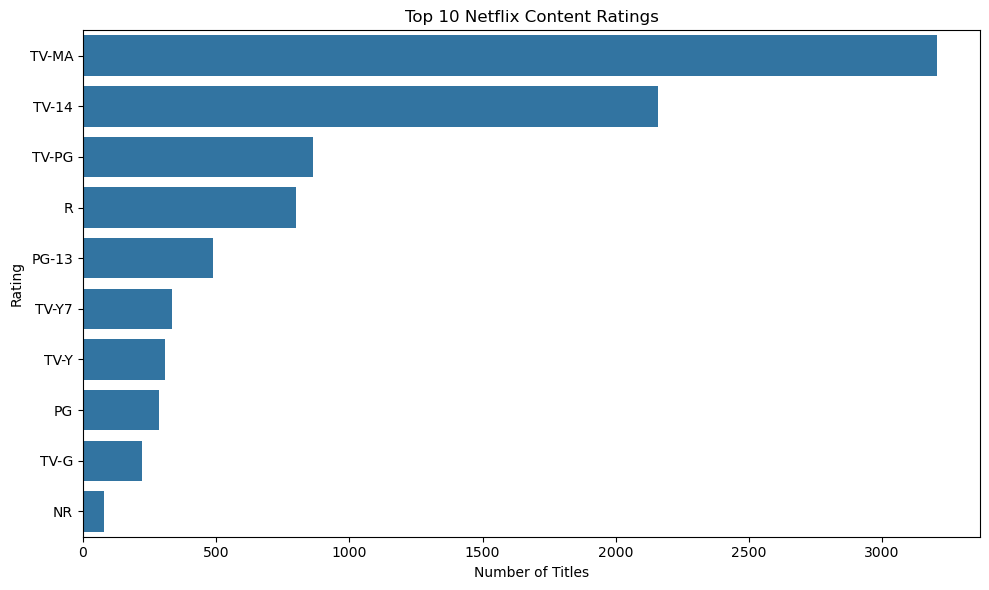

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rating_counts.head(10),
    x="Title Count",
    y="Rating"
)

plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

Step 5: Ratings by Content Type

In [61]:
# Step 5: Rating distribution by content type

rating_type = pd.crosstab(
    netflix["rating"],
    netflix["type"]
)

# Keep the 10 most common ratings
top_ratings = rating_counts.head(10)["Rating"]

rating_type_top10 = rating_type.loc[
    rating_type.index.isin(top_ratings)
]

display(rating_type_top10)

type,Movie,TV Show
rating,,
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94
TV-MA,2062,1145
TV-PG,540,323
TV-Y,131,176


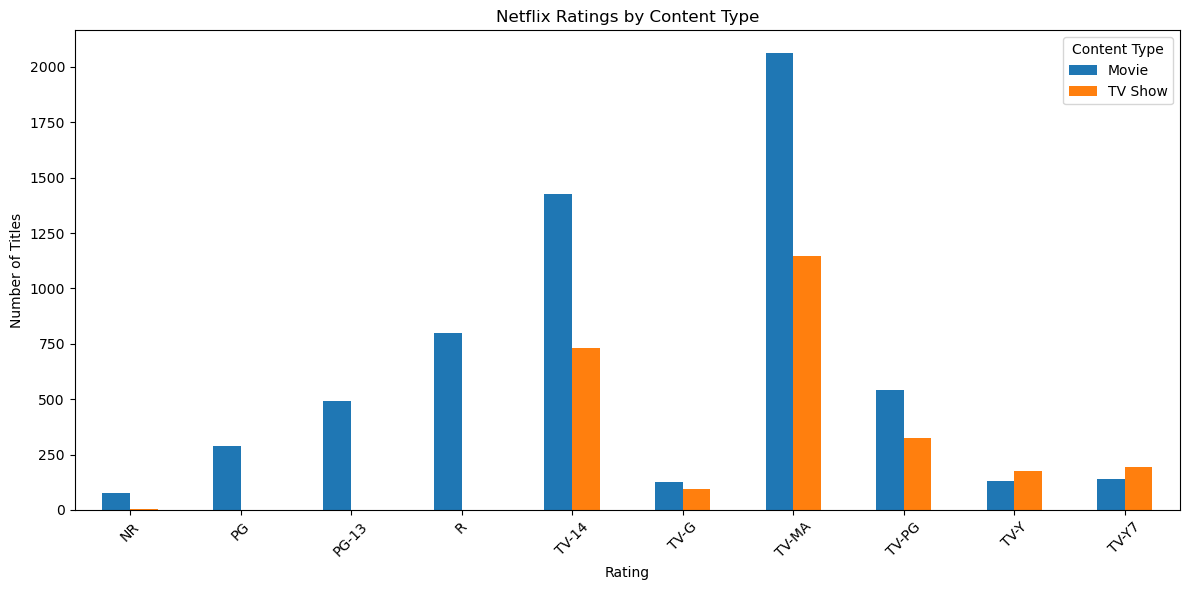

In [62]:
rating_type_top10.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Netflix Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Content Type")
plt.tight_layout()
plt.show()

Step 6: Regional Content Mix

In [63]:
# Step 6: Regional Content Analysis

country_df = netflix[["show_id", "type", "country"]].copy()

# Split multiple countries
country_df["country"] = country_df["country"].str.split(", ")

# Create one row per country-title association
country_df = country_df.explode("country")

# Remove Unknown
country_df = country_df[country_df["country"] != "Unknown"]

# Count titles by country
country_counts = (
    country_df["country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["Country", "Title Count"]

print("Total countries:", country_df["country"].nunique())

print("\nTop 10 countries:")
display(country_counts.head(10))

Total countries: 127

Top 10 countries:


,Country,Title Count
0,United States,3689
1,India,1046
2,United Kingdom,804
3,Canada,445
4,France,393
5,Japan,318
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


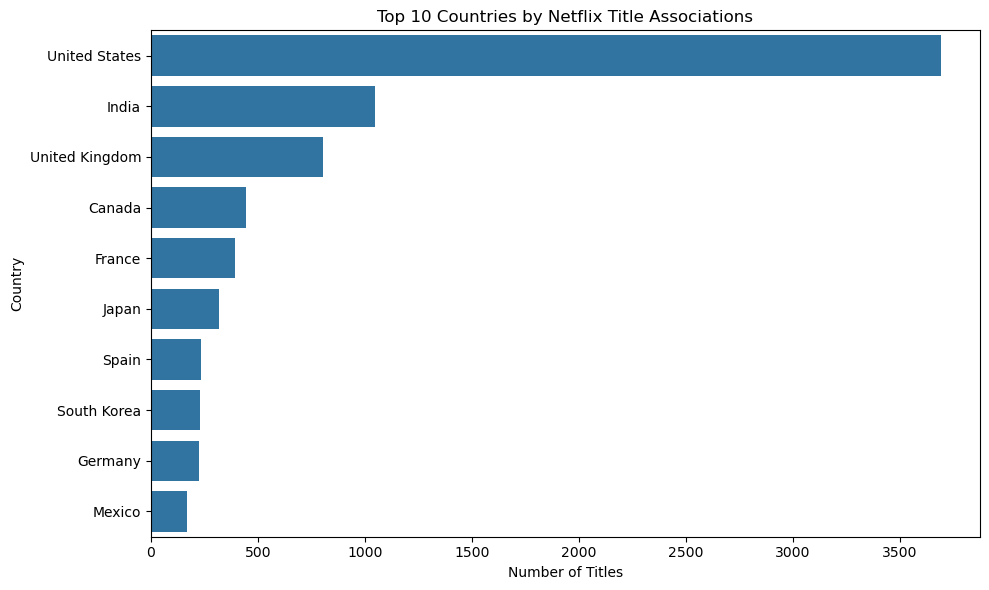

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=country_counts.head(10),
    x="Title Count",
    y="Country"
)

plt.title("Top 10 Countries by Netflix Title Associations")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Step 7: Regional Content Mix by Type

In [65]:
# Step 7: Country-wise content type analysis

country_type = (
    country_df
    .groupby(["country", "type"])
    .size()
    .reset_index(name="Title Count")
)

# Top 10 countries from Step 6
top_countries = country_counts.head(10)["Country"]

country_type_top10 = country_type[
    country_type["country"].isin(top_countries)
]

display(
    country_type_top10
    .sort_values(["country", "Title Count"], ascending=[True, False])
)

,country,type,Title Count
28,Canada,Movie,319
29,Canada,TV Show,126
53,France,Movie,303
54,France,TV Show,90
56,Germany,Movie,182
57,Germany,TV Show,44
68,India,Movie,962
69,India,TV Show,84
82,Japan,TV Show,199
81,Japan,Movie,119


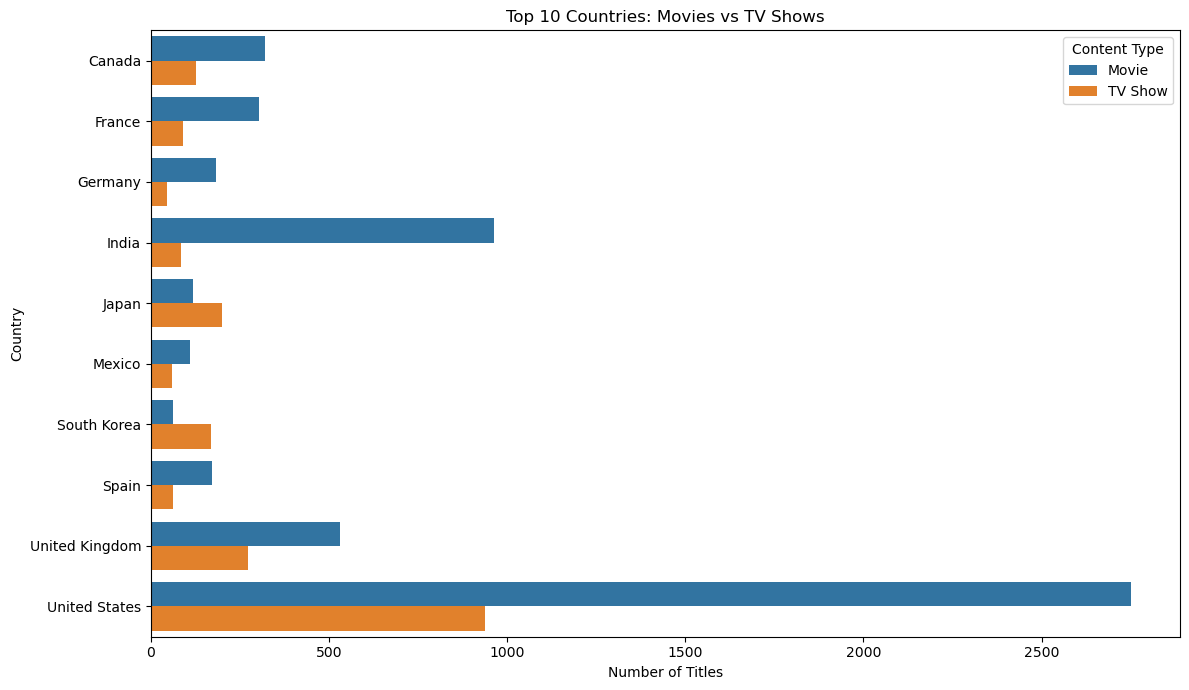

In [66]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=country_type_top10,
    x="Title Count",
    y="country",
    hue="type"
)

plt.title("Top 10 Countries: Movies vs TV Shows")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.legend(title="Content Type")
plt.tight_layout()
plt.show()

Step 8: Release Trends by Year

In [67]:
# Step 8: Release Trend Analysis

yearly_content = (
    netflix
    .groupby(["release_year", "type"])
    .size()
    .reset_index(name="Title Count")
)

yearly_pivot = (
    yearly_content
    .pivot(
        index="release_year",
        columns="type",
        values="Title Count"
    )
    .fillna(0)
)

display(yearly_pivot.tail(15))

type,Movie,TV Show
release_year,,
2007,74.0,14.0
2008,113.0,23.0
2009,118.0,34.0
2010,154.0,40.0
2011,145.0,40.0
2012,173.0,64.0
2013,225.0,63.0
2014,264.0,88.0
2015,398.0,162.0


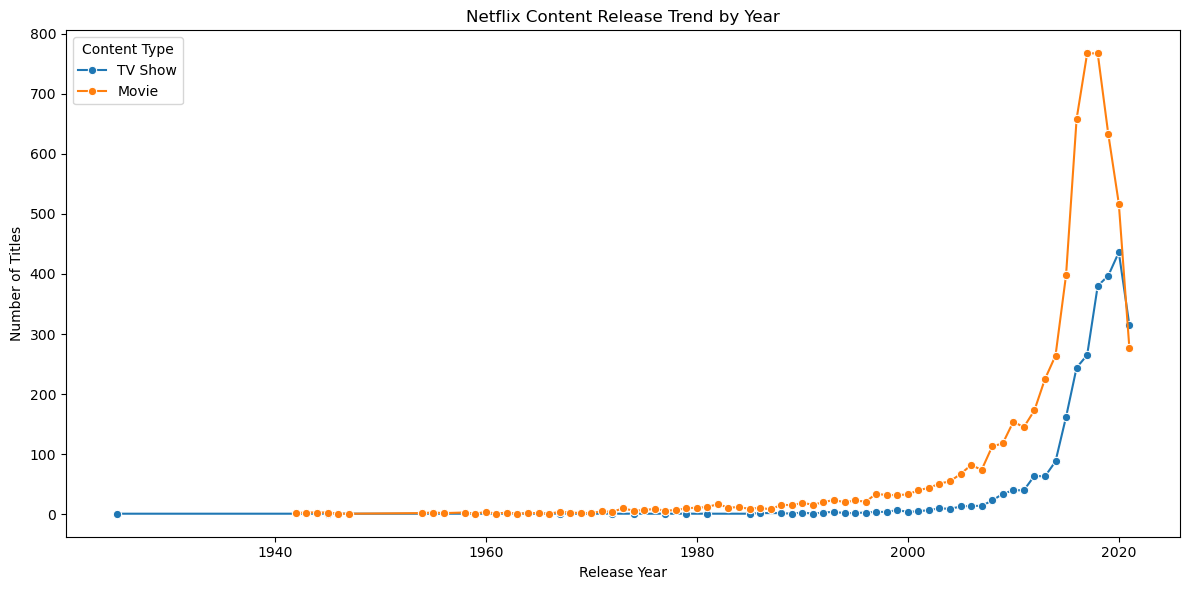

In [68]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_content,
    x="release_year",
    y="Title Count",
    hue="type",
    marker="o"
)

plt.title("Netflix Content Release Trend by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.tight_layout()
plt.show()

Step 9: Movie Duration vs TV Show Seasons

In [69]:
# Step 9: Duration Analysis

movies = netflix[netflix["type"] == "Movie"].copy()
tv_shows = netflix[netflix["type"] == "TV Show"].copy()

movie_duration = movies["duration_value"].dropna()

print("Average movie duration:", movie_duration.mean())
print("Median movie duration:", movie_duration.median())

print("\nMost common movie durations:")
display(
    movie_duration
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
    .reset_index(name="Title Count")
)

Average movie duration: 99.57718668407311
Median movie duration: 98.0

Most common movie durations:


,duration_value,Title Count
0,98.0,120
1,102.0,122
2,92.0,129
3,96.0,130
4,95.0,137
5,91.0,144
6,94.0,146
7,93.0,146
8,97.0,146
9,90.0,152


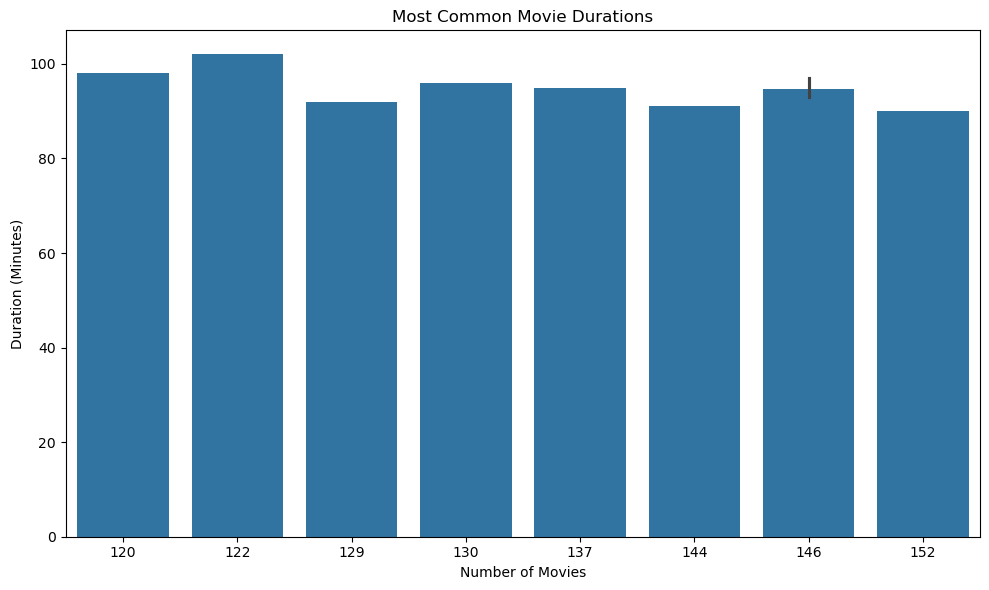

In [70]:
common_movie_durations = (
    movie_duration
    .value_counts()
    .head(10)
    .sort_values()
    .reset_index()
)

common_movie_durations.columns = ["Duration", "Title Count"]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_movie_durations,
    x="Title Count",
    y="Duration"
)

plt.title("Most Common Movie Durations")
plt.xlabel("Number of Movies")
plt.ylabel("Duration (Minutes)")
plt.tight_layout()
plt.show()

In [71]:
tv_seasons = tv_shows["duration_value"].dropna()

print("Average TV show seasons:", tv_seasons.mean())
print("Median TV show seasons:", tv_seasons.median())

print("\nTV Shows by number of seasons:")
display(
    tv_seasons
    .value_counts()
    .sort_index()
    .reset_index(name="Title Count")
)

Average TV show seasons: 1.764947683109118
Median TV show seasons: 1.0

TV Shows by number of seasons:


,duration_value,Title Count
0,1.0,1793
1,2.0,425
2,3.0,199
3,4.0,95
4,5.0,65
5,6.0,33
6,7.0,23
7,8.0,17
8,9.0,9
9,10.0,7


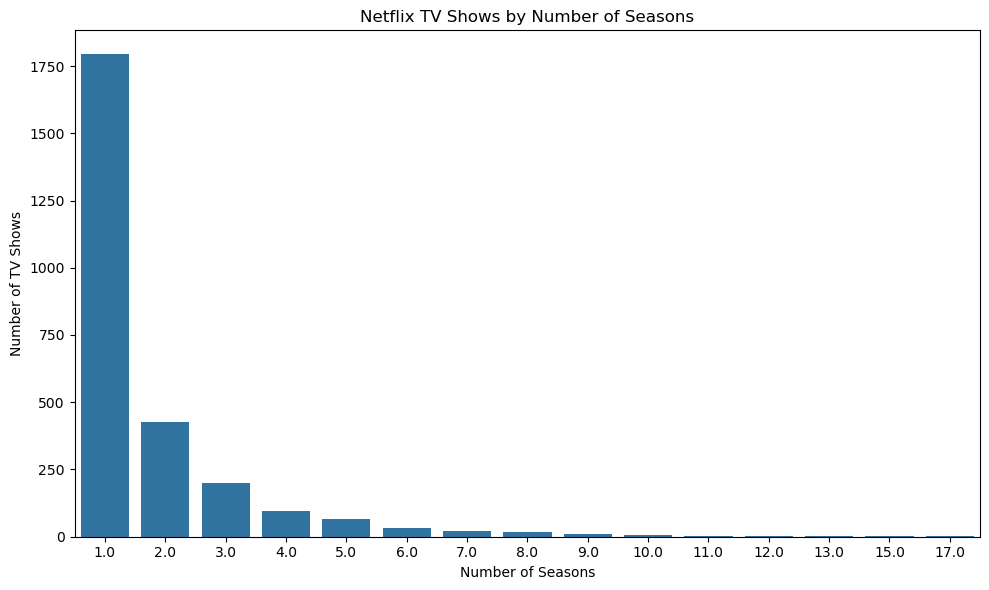

In [72]:
season_counts = (
    tv_seasons
    .value_counts()
    .sort_index()
    .reset_index()
)

season_counts.columns = ["Seasons", "Title Count"]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=season_counts,
    x="Seasons",
    y="Title Count"
)

plt.title("Netflix TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.tight_layout()
plt.show()

Step 10: Content Added to Netflix Over Time

In [73]:
# Step 10: Content Added Over Time

added_yearly = (
    netflix
    .dropna(subset=["year_added"])
    .groupby(["year_added", "type"])
    .size()
    .reset_index(name="Title Count")
)

added_year_pivot = (
    added_yearly
    .pivot(
        index="year_added",
        columns="type",
        values="Title Count"
    )
    .fillna(0)
)

display(added_year_pivot)

type,Movie,TV Show
year_added,,
2008.0,1.0,1.0
2009.0,2.0,0.0
2010.0,1.0,0.0
2011.0,13.0,0.0
2012.0,3.0,0.0
2013.0,6.0,5.0
2014.0,19.0,5.0
2015.0,56.0,26.0
2016.0,253.0,176.0


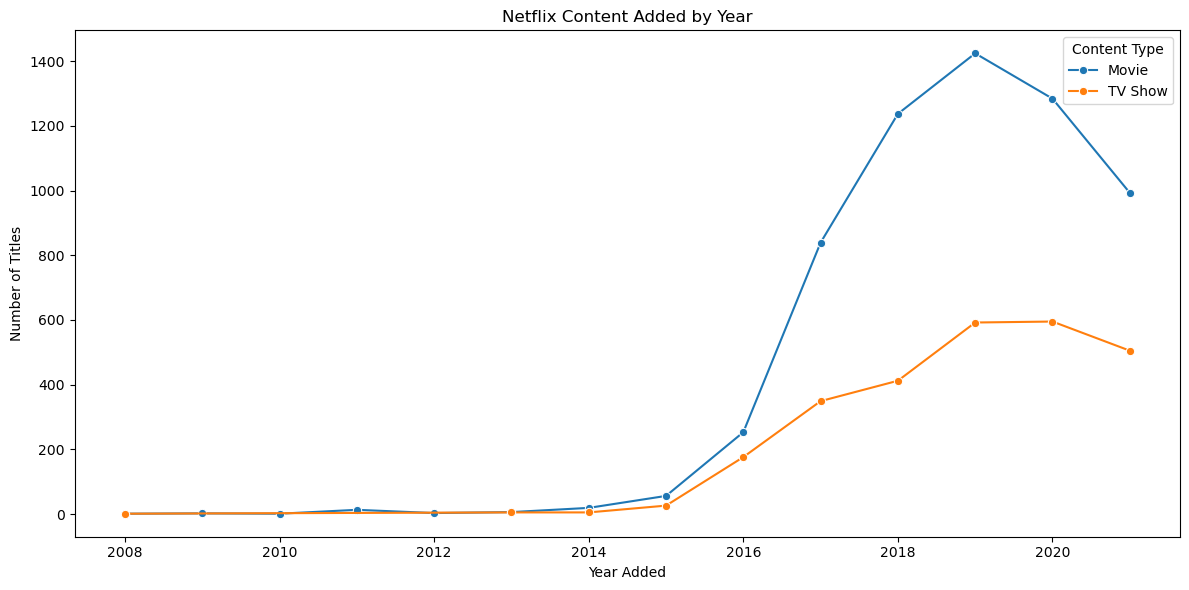

In [74]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=added_yearly,
    x="year_added",
    y="Title Count",
    hue="type",
    marker="o"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.tight_layout()
plt.show()

In [75]:
total_added_by_year = (
    netflix
    .dropna(subset=["year_added"])
    .groupby("year_added")
    .size()
    .sort_values(ascending=False)
)

print("Top 5 years by content additions:")
display(total_added_by_year.head(5))

Top 5 years by content additions:


year_added
2019.0    2016
2020.0    1879
2018.0    1649
2021.0    1498
2017.0    1188
dtype: int64

In [77]:
netflix.to_csv("netflix_cleaned.csv", index=False)

In [78]:
print(netflix.shape)
print(netflix.columns.tolist())

(8807, 15)
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'duration_value']


In [79]:
netflix.to_csv("netflix_cleaned.csv", index=False, encoding="utf-8")

In [80]:
with open("netflix_cleaned.csv", "r", encoding="utf-8") as f:
    lines = sum(1 for _ in f)

print("CSV lines:", lines)

CSV lines: 8810


In [81]:
import os

print(os.path.abspath("netflix_cleaned.csv"))

c:\Users\Bikash Mahato\Desktop\Veda\Day 32\netflix_cleaned.csv


In [82]:
import pandas as pd

# Create a copy
mysql_df = netflix.copy()

# Remove line breaks from text columns
text_columns = [
    "title",
    "director",
    "cast",
    "country",
    "listed_in",
    "description"
]

for col in text_columns:
    mysql_df[col] = (
        mysql_df[col]
        .astype(str)
        .str.replace("\r", " ", regex=False)
        .str.replace("\n", " ", regex=False)
    )

# Save a new CSV
mysql_df.to_csv(
    "netflix_mysql.csv",
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)

print("Rows:", len(mysql_df))
print("Columns:", len(mysql_df.columns))
print("File created: netflix_mysql.csv")

Rows: 8807
Columns: 15
File created: netflix_mysql.csv
